# Traducción Automática Neuronal – Alemán → Inglés con Keras
**Universidad de las Fuerzas Armadas ESPE** | **Minería de Datos | NRC: 30762**
**Estudiante:** Josue Zambrano | **Docente:** Ing. Estevan Ricardo Gómez Torres

Basado en: https://machinelearningmastery.com/develop-neural-machine-translation-system-keras/

## Celda 1 – Instalación y descarga del dataset

In [ ]:
# Instalamos dependencias
!pip install tensorflow keras nltk -q

import nltk
nltk.download('punkt')

# Descargamos el dataset alemán-inglés de Brownlee
!wget -q https://raw.githubusercontent.com/jbrownlee/Datasets/master/deu.txt

# Verificamos
!wc -l deu.txt
print('Dataset descargado correctamente: deu.txt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


152820 deu.txt
Dataset descargado correctamente: deu.txt


## Celda 2 – Limpieza y preparación del texto

In [ ]:
import string
import re
from pickle import dump
from unicodedata import normalize
from numpy import array

def load_doc(filename):
    file = open(filename, mode='rt', encoding='utf-8')
    text = file.read()
    file.close()
    return text

def to_pairs(doc):
    lines = doc.strip().split('\n')
    pairs = [line.split('\t') for line in lines]
    return pairs

def clean_pairs(lines):
    cleaned = list()
    re_print = re.compile('[^%s]' % re.escape(string.printable))
    table = str.maketrans('', '', string.punctuation)
    for pair in lines:
        clean_pair = list()
        for line in pair:
            line = normalize('NFD', line).encode('ascii', 'ignore')
            line = line.decode('UTF-8')
            line = line.split()
            line = [word.lower() for word in line]
            line = [word.translate(table) for word in line]
            line = [re_print.sub('', w) for w in line]
            line = [word for word in line if word.isalpha()]
            clean_pair.append(' '.join(line))
        cleaned.append(clean_pair)
    return array(cleaned)

def save_clean_data(sentences, filename):
    dump(sentences, open(filename, 'wb'))
    print('Saved: %s' % filename)

filename = 'deu.txt'
doc = load_doc(filename)
pairs = to_pairs(doc)
clean_pairs_data = clean_pairs(pairs)
save_clean_data(clean_pairs_data, 'english-german.pkl')

print('\nPrimeros 10 pares limpios:')
for i in range(10):
    print('[%s] => [%s]' % (clean_pairs_data[i,0], clean_pairs_data[i,1]))

Saved: english-german.pkl

Primeros 10 pares limpios:
[hi] => [hallo]
[hi] => [gru gott]
[run] => [lauf]
[wow] => [potzdonner]
[wow] => [donnerwetter]
[fire] => [feuer]
[help] => [hilfe]
[help] => [zu hulf]
[stop] => [stopp]
[wait] => [warte]


## Celda 3 – División del corpus en Train y Test

In [ ]:
from pickle import load, dump
from numpy.random import shuffle

def load_clean_sentences(filename):
    return load(open(filename, 'rb'))

def save_clean_data(sentences, filename):
    dump(sentences, open(filename, 'wb'))
    print('Saved: %s' % filename)

raw_dataset = load_clean_sentences('english-german.pkl')

# Seleccionamos los primeros 10,000 pares (los más cortos)
n_sentences = 10000
dataset = raw_dataset[:n_sentences, :]
shuffle(dataset)

# 9000 train, 1000 test
train, test = dataset[:9000], dataset[9000:]
save_clean_data(dataset, 'english-german-both.pkl')
save_clean_data(train,   'english-german-train.pkl')
save_clean_data(test,    'english-german-test.pkl')

print(f'\nTotal: {len(dataset)} | Train: {len(train)} | Test: {len(test)}')

Saved: english-german-both.pkl
Saved: english-german-train.pkl
Saved: english-german-test.pkl

Total: 10000 | Train: 9000 | Test: 1000


## Celda 4 – Definición y entrenamiento del modelo Encoder-Decoder

In [ ]:
from pickle import load
from numpy import array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import ModelCheckpoint

def load_clean_sentences(filename):
    return load(open(filename, 'rb'))

def create_tokenizer(lines):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(lines)
    return tokenizer

def max_length(lines):
    return max(len(line.split()) for line in lines)

def encode_sequences(tokenizer, length, lines):
    X = tokenizer.texts_to_sequences(lines)
    X = pad_sequences(X, maxlen=length, padding='post')
    return X

def encode_output(sequences, vocab_size):
    ylist = list()
    for sequence in sequences:
        encoded = to_categorical(sequence, num_classes=vocab_size)
        ylist.append(encoded)
    y = array(ylist)
    y = y.reshape(sequences.shape[0], sequences.shape[1], vocab_size)
    return y

def define_model(src_vocab, tar_vocab, src_timesteps, tar_timesteps, n_units):
    model = Sequential()
    model.add(Embedding(src_vocab, n_units,
                        input_length=src_timesteps, mask_zero=True))
    model.add(LSTM(n_units))
    model.add(RepeatVector(tar_timesteps))
    model.add(LSTM(n_units, return_sequences=True))
    model.add(TimeDistributed(Dense(tar_vocab, activation='softmax')))
    return model

# Cargamos datos
dataset = load_clean_sentences('english-german-both.pkl')
train   = load_clean_sentences('english-german-train.pkl')
test    = load_clean_sentences('english-german-test.pkl')

# Tokenizadores
eng_tokenizer  = create_tokenizer(dataset[:, 0])
eng_vocab_size = len(eng_tokenizer.word_index) + 1
eng_length     = max_length(dataset[:, 0])
print('English Vocabulary Size: %d' % eng_vocab_size)
print('English Max Length: %d'      % eng_length)

ger_tokenizer  = create_tokenizer(dataset[:, 1])
ger_vocab_size = len(ger_tokenizer.word_index) + 1
ger_length     = max_length(dataset[:, 1])
print('German Vocabulary Size: %d'  % ger_vocab_size)
print('German Max Length: %d'       % ger_length)

# Preparamos datos
trainX = encode_sequences(ger_tokenizer, ger_length, train[:, 1])
trainY = encode_sequences(eng_tokenizer, eng_length, train[:, 0])
trainY = encode_output(trainY, eng_vocab_size)
testX  = encode_sequences(ger_tokenizer, ger_length, test[:, 1])
testY  = encode_sequences(eng_tokenizer, eng_length, test[:, 0])
testY  = encode_output(testY, eng_vocab_size)

# Definimos y entrenamos el modelo
model = define_model(ger_vocab_size, eng_vocab_size,
                     ger_length, eng_length, 256)
model.compile(optimizer='adam', loss='categorical_crossentropy')
print(model.summary())

filename   = 'model.h5'
checkpoint = ModelCheckpoint(filename, monitor='val_loss',
                             verbose=1, save_best_only=True, mode='min')
model.fit(trainX, trainY, epochs=30, batch_size=64,
          validation_data=(testX, testY),
          callbacks=[checkpoint], verbose=2)

English Vocabulary Size: 2404
English Max Length: 5
German Vocabulary Size: 3856
German Max Length: 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...


Epoch 24: finished saving model to model.h5
141/141 - 2s - 11ms/step - loss: 0.9103 - val_loss: 2.1216
Epoch 25/30

Epoch 25: val_loss improved from 2.12156 to 2.10535, saving model to model.h5



Epoch 25: finished saving model to model.h5
141/141 - 2s - 11ms/step - loss: 0.8415 - val_loss: 2.1054
Epoch 26/30

Epoch 26: val_loss improved from 2.10535 to 2.08711, saving model to model.h5



Epoch 26: finished saving model to model.h5
141/141 - 2s - 15ms/step - loss: 0.7727 - val_loss: 2.0871
Epoch 27/30

Epoch 27: val_loss improved from 2.08711 to 2.08646, saving model to model.h5



Epoch 27: finished saving model to model.h5
141/141 - 2s - 17ms/step - loss: 0.7143 - val_loss: 2.0865
Epoch 28/30

Epoch 28: val_loss did not improve from 2.08646
141/141 - 2s - 12ms/step - loss: 0.6524 - val_loss: 2.0890
Epoch 29/30

Epoch 29: val_loss improved from 2.08646 to 2.06845, saving model to model.h5



Epoch 29: finished saving model to model.h5
141/141 - 1s - 10ms/step - loss: 0.5996 - val_loss: 2.0684
Epoch 30/30

Epoch 30: val_loss did not improve from 2.06845
141/141 - 1s - 10ms/step - loss: 0.5519 - val_loss: 2.0691


## Celda 5 – Evaluación del modelo con BLEU

In [ ]:
from pickle import load
from numpy import array, argmax
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from nltk.translate.bleu_score import corpus_bleu

def load_clean_sentences(filename):
    return load(open(filename, 'rb'))

def create_tokenizer(lines):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(lines)
    return tokenizer

def max_length(lines):
    return max(len(line.split()) for line in lines)

def encode_sequences(tokenizer, length, lines):
    X = tokenizer.texts_to_sequences(lines)
    X = pad_sequences(X, maxlen=length, padding='post')
    return X

def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def predict_sequence(model, tokenizer, source):
    prediction = model.predict(source, verbose=0)[0]
    integers   = [argmax(vector) for vector in prediction]
    target = []
    for i in integers:
        word = word_for_id(i, tokenizer)
        if word is None:
            break
        target.append(word)
    return ' '.join(target)

def evaluate_model(model, tokenizer, sources, raw_dataset):
    actual, predicted = list(), list()
    for i, source in enumerate(sources):
        source      = source.reshape((1, source.shape[0]))
        translation = predict_sequence(model, tokenizer, source)
        raw_target, raw_src = raw_dataset[i]
        if i < 10:
            print('src=[%s], target=[%s], predicted=[%s]'
                  % (raw_src, raw_target, translation))
        actual.append([raw_target.split()])
        predicted.append(translation.split())
    print('BLEU-1: %f' % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
    print('BLEU-2: %f' % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))
    print('BLEU-3: %f' % corpus_bleu(actual, predicted, weights=(0.3, 0.3, 0.3, 0)))
    print('BLEU-4: %f' % corpus_bleu(actual, predicted, weights=(.25,.25,.25,.25)))

# Cargamos datos y modelo
dataset = load_clean_sentences('english-german-both.pkl')
train   = load_clean_sentences('english-german-train.pkl')
test    = load_clean_sentences('english-german-test.pkl')

eng_tokenizer  = create_tokenizer(dataset[:, 0])
eng_vocab_size = len(eng_tokenizer.word_index) + 1
eng_length     = max_length(dataset[:, 0])
ger_tokenizer  = create_tokenizer(dataset[:, 1])
ger_length     = max_length(dataset[:, 1])

trainX = encode_sequences(ger_tokenizer, ger_length, train[:, 1])
testX  = encode_sequences(ger_tokenizer, ger_length, test[:, 1])
model  = load_model('model.h5')

print('=== EVALUACIÓN EN ENTRENAMIENTO ===')
evaluate_model(model, eng_tokenizer, trainX, train)
print('\n=== EVALUACIÓN EN PRUEBA ===')
evaluate_model(model, eng_tokenizer, testX, test)

=== EVALUACIÓN EN ENTRENAMIENTO ===
src=[tom hat eine erkaltung], target=[tom has a cold], predicted=[tom has a cold]
src=[ist das gesetzlich zugelassen], target=[is it legal], predicted=[is it legal]
src=[warten sie nicht], target=[dont wait], predicted=[dont wait]
src=[dreh es auf], target=[loosen it], predicted=[loosen it]
src=[versuchen sies doch mal], target=[give it a shot], predicted=[give it a]
src=[lach nicht], target=[dont laugh], predicted=[dont laugh]
src=[tom ist gut gelaunt], target=[toms cheerful], predicted=[toms cheerful]
src=[konnen wir hier schwimmen], target=[can we swim here], predicted=[can we swim]
src=[ich bin beschaftigt gewesen], target=[i have been busy], predicted=[i never been busy]
src=[er ist schriftsteller], target=[he is a writer], predicted=[he is a]
BLEU-1: 0.827573
BLEU-2: 0.761327
BLEU-3: 0.675489
BLEU-4: 0.428193

=== EVALUACIÓN EN PRUEBA ===
src=[gib tom einen kuss von mir], target=[kiss tom for me], predicted=[give tom a kiss]
src=[ubernimm das k

## Celda 6 – Visualización de resultados BLEU

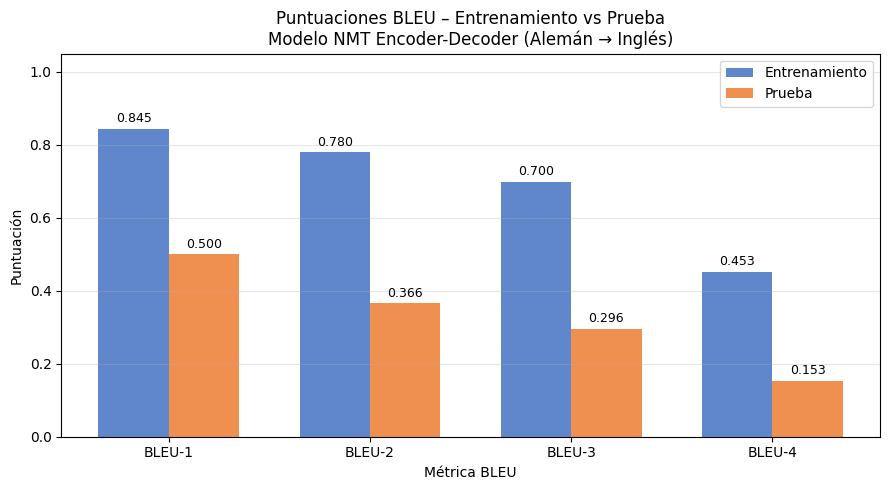

Gráfico guardado como bleu_scores.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Resultados BLEU obtenidos
metricas = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
train_scores = [0.8449, 0.7798, 0.6995, 0.4526]
test_scores  = [0.4996, 0.3659, 0.2958, 0.1535]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, train_scores, width,
               label='Entrenamiento', color='#4472C4', alpha=0.85)
bars2 = ax.bar(x + width/2, test_scores,  width,
               label='Prueba',         color='#ED7D31', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Métrica BLEU')
ax.set_ylabel('Puntuación')
ax.set_title('Puntuaciones BLEU – Entrenamiento vs Prueba\nModelo NMT Encoder-Decoder (Alemán → Inglés)')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bleu_scores.png', dpi=150)
plt.show()
print('Gráfico guardado como bleu_scores.png')